<span style="color: purple;">**СРАВНЕНИЕ МОДЕЛЕЙ МАШИННОГО ОБУЧЕНИЯ ДЛЯ ПРОГНОЗИРОВАНИЯ ЦЕН АКЦИЙ**</span>

Машинное обучение – это направление искусственного интеллекта, которое позволяет компьютерам учиться решать задачи на основе опыта, не будучи явно запрограммированными для каждой конкретной ситуации. Сегодня машинное обучение – не только предмет исследований в области компьютерных наук, оно играет важную роль во многих сферах экономики, а также в нашей повседневной жизни, в том числе алгоритмы машинного обучения активно применяются в сфере торговли на фондовом рынке.

В данном итоговом проекте рассмотрим тему: «Сравнение моделей машинного обучения для прогнозирования цен акций». Цель проекта: сравнение моделей машинного обучения для прогнозирования цен акций и определение модели, которая будет обладать высокой обобщающей способностью, то есть будет давать достаточно точные предсказания на новых, ранее не встречавшихся данных. Задачи проекта: исследование данных о фондовом рынке, разработка моделей с использованием различных алгоритмов машинного обучения, сравнительный анализ моделей, демонстрация навыков создания программного кода на языке Python с применением различных библиотек, придерживаясь единого стиля оформления (PEP 8).



<span style="color: orange;">**1. Проведение исследовательского анализа данных (Exploratory Data Analysis - EDA).**</span>

Импортируем библиотеки для подсчета времени обучения модели, работы с массивами данных, выполнения математических операций, обработки и анализа структурированных табличных данных, визуализации данных, кодирования категориальных переменных, проведения теста Дика-Фуллера, реализации модели ARIMA, разделения данных на тренировочную и тестовую выборки, настройки гиперпараметров модели, стандартизации данных, реализации модели линейной регрессии, реализации модели случайного леса для регрессии, создания ансамбля моделей, оценки качества модели, реализации модели градиентного бустинга для регрессии.

In [1]:
from time import perf_counter

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce

In [3]:
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

In [4]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import lightgbm as lgb

Загружаем данные из csv-файла. Прописывается путь, где размещен файл с данными, затем с помощью функции pd.read_csv() выполняется чтение данных из csv-файла. Используется функция display() вместо print() для более удобного отображения таблицы.

In [8]:
data = pd.read_csv("stock_details_5_years.csv")
display(pd.read_csv("stock_details_5_years.csv"))

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29 00:00:00-05:00,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29 00:00:00-05:00,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29 00:00:00-05:00,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA
...,...,...,...,...,...,...,...,...,...
602957,2023-11-29 00:00:00-05:00,26.360001,26.397499,26.120001,26.150000,1729147,0.00,0.0,PPL
602958,2023-11-29 00:00:00-05:00,27.680000,28.535000,27.680000,28.350000,1940066,0.00,0.0,FITB
602959,2023-11-29 00:00:00-05:00,75.940002,76.555000,75.257500,75.610001,298699,0.00,0.0,IFF
602960,2023-11-29 00:00:00-05:00,45.230000,45.259998,44.040001,44.209999,2217579,0.00,0.0,CCJ


Набор данных взят с сайта www.kaggle.com и содержит исторические данные о фондовом рынке, извлеченные из Yahoo Finance. Набор данных включает следующие столбцы: «Date» – дата, соответствующая зафиксированным данным фондового рынка; «Open» – цена открытия торгов акциями на определенную дату; «High» – максимальная цена акции, зафиксированная в течение торгового дня; «Low» – минимальная цена акции, зафиксированная в течение торгового дня; «Close» – цена закрытия торгов акциями на определенную дату; «Volume» – объем акций, проданных в определенную дату; «Dividends» – дивидендные выплаты, произведенные компанией на определенную дату; «Stock Splits» – информация о дроблении акций, произошедшем в определенную дату; «Company» – краткое буквенное обозначение компании. Набор данных содержит 602 962 строки и 9 столбцов.

С помощью метода info() выводим краткую оценку структуры и качества набора данных: количество строк и столбцов, названия и тип данных столбцов, количество ненулевых значений в столбцах, общее использование памяти. Данный метод удобен тем, что собирает в единое целое краткую информацию о наборе данных.

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602962 entries, 0 to 602961
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          602962 non-null  object 
 1   Open          602962 non-null  float64
 2   High          602962 non-null  float64
 3   Low           602962 non-null  float64
 4   Close         602962 non-null  float64
 5   Volume        602962 non-null  int64  
 6   Dividends     602962 non-null  float64
 7   Stock Splits  602962 non-null  float64
 8   Company       602962 non-null  object 
dtypes: float64(6), int64(1), object(2)
memory usage: 41.4+ MB


С помощью метода describe() выводим статистические характеристики числовых столбцов: количество заполненных строк в каждом столбце; среднее значение; стандартное отклонение, показывающее разброс значений; минимальное и максимальное значения; значения по процентилям, показывающие распределение значений в выборке. 25-й процентиль (первый квартиль) показывает нижнюю границу средней половины данных, то есть 25% значений находятся ниже. 50-й процентиль (медиана) делит данные пополам и является мерой центральной тенденции. 75% процентиль (третий квартиль) показывает верхнюю границу средней половины данных, то есть 75% значений находятся ниже. 

In [10]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,602962.000000,602962.000000,602962.000000,602962.000000,6.029620e+05,602962.00000,602962.000000
mean,140.074711,141.853492,138.276316,140.095204,5.895601e+06,0.00731,0.000344
std,275.401725,279.003191,271.895276,275.477969,1.381596e+07,0.12057,0.050607
min,1.052425,1.061195,1.026114,1.034884,0.000000e+00,0.00000,0.000000
25%,39.566159,40.056222,39.058151,39.563746,1.031500e+06,0.00000,0.000000
50%,79.177964,80.125563,78.193820,79.177906,2.228700e+06,0.00000,0.000000
75%,157.837190,159.746317,155.841609,157.847153,5.277400e+06,0.00000,0.000000
max,6490.259766,6525.000000,6405.000000,6509.350098,1.123003e+09,35.00000,20.000000


Округляем статистические характеристики до целых чисел.

In [11]:
with pd.option_context('display.float_format', '{:.0f}'.format):
    display(data.describe())

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,602962,602962,602962,602962,602962,602962,602962
mean,140,142,138,140,5895601,0,0
std,275,279,272,275,13815962,0,0
min,1,1,1,1,0,0,0
25%,40,40,39,40,1031500,0,0
50%,79,80,78,79,2228700,0,0
75%,158,160,156,158,5277400,0,0
max,6490,6525,6405,6509,1123003300,35,20


В наборе данных содержится информация по акциям 491 компании. Для вывода всех компаний и подсчета их количества используем методы unique() и nunique().

In [12]:
unique_values_company = data['Company'].unique()
print("Перечень компаний:", unique_values_company)

Перечень компаний: ['AAPL' 'MSFT' 'GOOGL' 'AMZN' 'NVDA' 'META' 'TSLA' 'LLY' 'V' 'TSM' 'UNH'
 'AVGO' 'NVO' 'JPM' 'WMT' 'XOM' 'MA' 'JNJ' 'PG' 'ORCL' 'HD' 'ADBE' 'ASML'
 'CVX' 'COST' 'TM' 'MRK' 'KO' 'ABBV' 'BAC' 'PEP' 'FMX' 'CRM' 'SHEL' 'ACN'
 'NFLX' 'MCD' 'AMD' 'LIN' 'NVS' 'AZN' 'CSCO' 'TMO' 'BABA' 'INTC' 'PDD'
 'SAP' 'ABT' 'TMUS' 'PFE' 'DIS' 'NKE' 'CMCSA' 'DHR' 'INTU' 'TTE' 'WFC'
 'VZ' 'BHP' 'HDB' 'HSBC' 'PM' 'QCOM' 'IBM' 'AMGN' 'TXN' 'NOW' 'BA' 'COP'
 'UNP' 'BX' 'SPGI' 'UPS' 'GE' 'MS' 'HON' 'CAT' 'AMAT' 'BUD' 'AXP' 'RY'
 'NEE' 'UL' 'SNY' 'RTX' 'T' 'LOW' 'SBUX' 'RIO' 'TD' 'SYK' 'BLK' 'LMT' 'GS'
 'ELV' 'ISRG' 'BKNG' 'SONY' 'MDT' 'PLD' 'SCHW' 'DE' 'MUFG' 'BP' 'TJX'
 'BMY' 'PBR' 'MMC' 'MDLZ' 'AMT' 'PGR' 'LRCX' 'SHOP' 'ADP' 'EQNR' 'GILD'
 'CB' 'ADI' 'PANW' 'VRTX' 'ETN' 'UBS' 'CVS' 'C' 'REGN' 'KKR' 'MU' 'SNPS'
 'CI' 'MELI' 'BSX' 'ZTS' 'IBN' 'DEO' 'FI' 'CME' 'SO' 'EQIX' 'CDNS' 'KLAC'
 'SLB' 'MO' 'CNI' 'ENB' 'NTES' 'INFY' 'ITW' 'RELX' 'GSK' 'EOG' 'CNQ' 'BTI'
 'SHW' 'NOC' 'DUK' 'WDAY' 'BDX' 'AN

In [13]:
unique_count_company = data['Company'].nunique()
print(f"Количество компаний: {unique_count_company}")

Количество компаний: 491


Столбец «Date» с помощью метода astype(str) преобразуем в строковый тип данных, затем с помощью метода str.slice() извлекаем часть строки: год, месяц, день, указанные через дефис и с помощью метода to_datetime() преобразуем в тип данных для хранения дат.

In [14]:
data['Date'] = data['Date'].astype(str).str.slice(0, 10)
data['Date'] = pd.to_datetime(data['Date'])

display(data)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA
...,...,...,...,...,...,...,...,...,...
602957,2023-11-29,26.360001,26.397499,26.120001,26.150000,1729147,0.00,0.0,PPL
602958,2023-11-29,27.680000,28.535000,27.680000,28.350000,1940066,0.00,0.0,FITB
602959,2023-11-29,75.940002,76.555000,75.257500,75.610001,298699,0.00,0.0,IFF
602960,2023-11-29,45.230000,45.259998,44.040001,44.209999,2217579,0.00,0.0,CCJ


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602962 entries, 0 to 602961
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Date          602962 non-null  datetime64[ns]
 1   Open          602962 non-null  float64       
 2   High          602962 non-null  float64       
 3   Low           602962 non-null  float64       
 4   Close         602962 non-null  float64       
 5   Volume        602962 non-null  int64         
 6   Dividends     602962 non-null  float64       
 7   Stock Splits  602962 non-null  float64       
 8   Company       602962 non-null  object        
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 41.4+ MB


Преобразовав с помощью pivot строки с указанием компаний в столбцы, выводим цену закрытия торгов по датам в виде нового датасета data_close. Такое преобразование позволяет понять, что по некоторым компаниям данные имеются не по всем датам. Методом isnull().sum() подсчитываем количество пропущенных значений. Затем полученную информацию преобразуем в DataFrame. Методом reset_index() преобразуем индекс в столбец. С помощью функции rename() переименовываем столбец с количеством пропущенных значений.

In [16]:
data_close = data.pivot(
    index='Date',
    columns='Company',
    values='Close'
)

display(data_close)

Company,A,AAPL,ABBV,ABEV,ABNB,ABT,ACGL,ACN,ADBE,ADI,...,WTW,WY,XEL,XOM,XYL,YUM,ZBH,ZM,ZS,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-11-29,69.001251,43.083508,71.184914,3.631820,NaN,67.365654,28.379999,150.171722,249.089996,81.795799,...,147.668747,21.815151,44.753716,61.217907,67.074562,83.960030,107.434830,NaN,37.560001,89.673248
2018-11-30,69.753235,42.850754,74.636864,3.606481,NaN,68.092094,28.620001,153.388290,250.889999,83.988708,...,148.563202,21.545931,45.552742,61.558617,68.655006,84.289078,109.359970,NaN,39.259998,90.736526
2018-12-03,71.989975,44.348064,74.153923,3.648712,NaN,68.294380,28.389999,155.532669,255.259995,85.441521,...,150.137817,21.619356,45.978298,62.890438,68.015305,84.151978,108.817947,NaN,39.119999,90.446533
2018-12-04,70.293159,42.397247,71.691612,3.606481,NaN,65.747253,27.940001,153.099289,245.820007,82.636406,...,146.569305,20.493515,45.882774,61.504402,64.007759,82.881523,104.659248,NaN,37.209999,87.546684
2018-12-06,69.329056,41.924541,71.517448,3.522021,NaN,65.784035,27.750000,148.474899,250.630005,81.804947,...,145.441925,21.815151,46.212795,60.699108,62.869465,83.631004,105.519012,NaN,42.980000,87.392029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-22,123.989998,191.309998,138.470001,2.760000,129.039993,102.699997,85.949997,333.130005,619.719971,182.669998,...,244.470001,31.990000,60.430000,104.010002,102.220001,128.332977,113.830002,63.830002,190.639999,179.350006
2023-11-24,126.620003,189.970001,138.669998,2.750000,128.369995,102.870003,86.599998,334.040009,619.429993,183.050003,...,244.279999,31.940001,60.520000,104.570000,103.260002,127.904991,113.430000,64.529999,193.089996,180.210007
2023-11-27,125.010002,189.789993,139.089996,2.760000,129.000000,102.709999,87.000000,332.429993,619.270020,183.770004,...,245.039993,31.620001,60.450001,103.959999,103.180000,127.690002,113.839996,65.550003,191.910004,178.789993


In [17]:
missing_values = data_close.isnull().sum()
print(missing_values)

Company
A         0
AAPL      0
ABBV      0
ABEV      0
ABNB    511
       ... 
YUM       0
ZBH       0
ZM       95
ZS        0
ZTS       0
Length: 491, dtype: int64


In [18]:
df_missing_values = pd.DataFrame(missing_values)
print(df_missing_values)

           0
Company     
A          0
AAPL       0
ABBV       0
ABEV       0
ABNB     511
...      ...
YUM        0
ZBH        0
ZM        95
ZS         0
ZTS        0

[491 rows x 1 columns]


In [19]:
df_missing_values = df_missing_values.reset_index()
print(df_missing_values)

    Company    0
0         A    0
1      AAPL    0
2      ABBV    0
3      ABEV    0
4      ABNB  511
..      ...  ...
486     YUM    0
487     ZBH    0
488      ZM   95
489      ZS    0
490     ZTS    0

[491 rows x 2 columns]


In [20]:
df_missing_values = df_missing_values.rename(
    columns={0: 'Count_missing_values'}
)

print(df_missing_values)

    Company  Count_missing_values
0         A                     0
1      AAPL                     0
2      ABBV                     0
3      ABEV                     0
4      ABNB                   511
..      ...                   ...
486     YUM                     0
487     ZBH                     0
488      ZM                    95
489      ZS                     0
490     ZTS                     0

[491 rows x 2 columns]


Таким образом, выводим перечень компаний с пропущенными значениями.

In [21]:
missing_values_company = df_missing_values[
    df_missing_values['Count_missing_values'] != 0
]

display(missing_values_company)

,Company,Count_missing_values
4,ABNB,511
19,ALC,88
38,ARM,1204
54,BEKE,428
67,BNTX,216
78,CARR,326
88,CEG,789
103,COIN,595
108,CPNG,572
113,CRWD,132


Пропущенные значения заменяем на «серединное» значение – медиану, используя функцию fillna(). Изменения применяем непосредственно к датасету data_close, поэтому указываем inplace=True. Медиана устойчива к выбросам, более подходит к асимметричным данным, уменьшает влияние экстремальных данных. Среднее же значение более подходит для нормально распределенных данных, а мода – для данных с явным преобладанием одного значения. Поэтому в данном случае целесообразно использовать медиану.

In [22]:
for i in data_close.columns:
    data_close[i] = data_close[i].fillna(data_close[i].median())

display(data_close)

Company,A,AAPL,ABBV,ABEV,ABNB,ABT,ACGL,ACN,ADBE,ADI,...,WTW,WY,XEL,XOM,XYL,YUM,ZBH,ZM,ZS,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-11-29,69.001251,43.083508,71.184914,3.631820,137.210007,67.365654,28.379999,150.171722,249.089996,81.795799,...,147.668747,21.815151,44.753716,61.217907,67.074562,83.960030,107.434830,106.099998,37.560001,89.673248
2018-11-30,69.753235,42.850754,74.636864,3.606481,137.210007,68.092094,28.620001,153.388290,250.889999,83.988708,...,148.563202,21.545931,45.552742,61.558617,68.655006,84.289078,109.359970,106.099998,39.259998,90.736526
2018-12-03,71.989975,44.348064,74.153923,3.648712,137.210007,68.294380,28.389999,155.532669,255.259995,85.441521,...,150.137817,21.619356,45.978298,62.890438,68.015305,84.151978,108.817947,106.099998,39.119999,90.446533
2018-12-04,70.293159,42.397247,71.691612,3.606481,137.210007,65.747253,27.940001,153.099289,245.820007,82.636406,...,146.569305,20.493515,45.882774,61.504402,64.007759,82.881523,104.659248,106.099998,37.209999,87.546684
2018-12-06,69.329056,41.924541,71.517448,3.522021,137.210007,65.784035,27.750000,148.474899,250.630005,81.804947,...,145.441925,21.815151,46.212795,60.699108,62.869465,83.631004,105.519012,106.099998,42.980000,87.392029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-22,123.989998,191.309998,138.470001,2.760000,129.039993,102.699997,85.949997,333.130005,619.719971,182.669998,...,244.470001,31.990000,60.430000,104.010002,102.220001,128.332977,113.830002,63.830002,190.639999,179.350006
2023-11-24,126.620003,189.970001,138.669998,2.750000,128.369995,102.870003,86.599998,334.040009,619.429993,183.050003,...,244.279999,31.940001,60.520000,104.570000,103.260002,127.904991,113.430000,64.529999,193.089996,180.210007
2023-11-27,125.010002,189.789993,139.089996,2.760000,129.000000,102.709999,87.000000,332.429993,619.270020,183.770004,...,245.039993,31.620001,60.450001,103.959999,103.180000,127.690002,113.839996,65.550003,191.910004,178.789993


Используя датасет data_close подсчитываем функцией mean() среднюю цену закрытия торгов по компаниям за весь период наблюдения и преобразовываем полученные данные в DataFrame. Среднее значение считается по каждому столбцу.

In [23]:
mean_close = data_close.mean(axis=0)

print(
    "Средняя цена закрытия торгов по компаниям "
    "за весь период наблюдения:\n",
    mean_close
)

Средняя цена закрытия торгов по компаниям за весь период наблюдения:
 Company
A       111.862449
AAPL    118.992628
ABBV    104.811102
ABEV      2.945837
ABNB    138.458842
           ...    
YUM     107.732138
ZBH     126.215307
ZM      168.821307
ZS      143.463382
ZTS     153.390256
Length: 491, dtype: float64


In [24]:
df_mean_close = pd.DataFrame(mean_close)
print(df_mean_close)

                  0
Company            
A        111.862449
AAPL     118.992628
ABBV     104.811102
ABEV       2.945837
ABNB     138.458842
...             ...
YUM      107.732138
ZBH      126.215307
ZM       168.821307
ZS       143.463382
ZTS      153.390256

[491 rows x 1 columns]


In [25]:
df_mean_close = df_mean_close.reset_index()
print(df_mean_close)

    Company           0
0         A  111.862449
1      AAPL  118.992628
2      ABBV  104.811102
3      ABEV    2.945837
4      ABNB  138.458842
..      ...         ...
486     YUM  107.732138
487     ZBH  126.215307
488      ZM  168.821307
489      ZS  143.463382
490     ZTS  153.390256

[491 rows x 2 columns]


In [26]:
df_mean_close = df_mean_close.rename(
    columns={0: 'Mean_Close'}
)

display(df_mean_close)

,Company,Mean_Close
0,A,111.862449
1,AAPL,118.992628
2,ABBV,104.811102
3,ABEV,2.945837
4,ABNB,138.458842
...,...,...
486,YUM,107.732138
487,ZBH,126.215307
488,ZM,168.821307
489,ZS,143.463382


In [27]:
df_mean_close.describe()

,Mean_Close
count,491.000000
mean,138.033386
std,260.781588
min,2.102599
25%,42.389239
50%,80.821562
75%,154.630123
max,4369.628335


Имеется существенный разброс в данных. Построим диаграмму рассеяния значений средней цены закрытия торгов по компаниям за весь период наблюдения. Используем функцию plt.scatter(). Настраиваем размеры и цвет, убираем наименования компаний для лучшей читаемости. Настраиваем параметры делений на осях: применяем настройки к обеим осям, выводим основные деления, задаем размер шрифта меток делений. Добавляем сетку и задаем автоматическую настройку расположения элементов диаграммы.

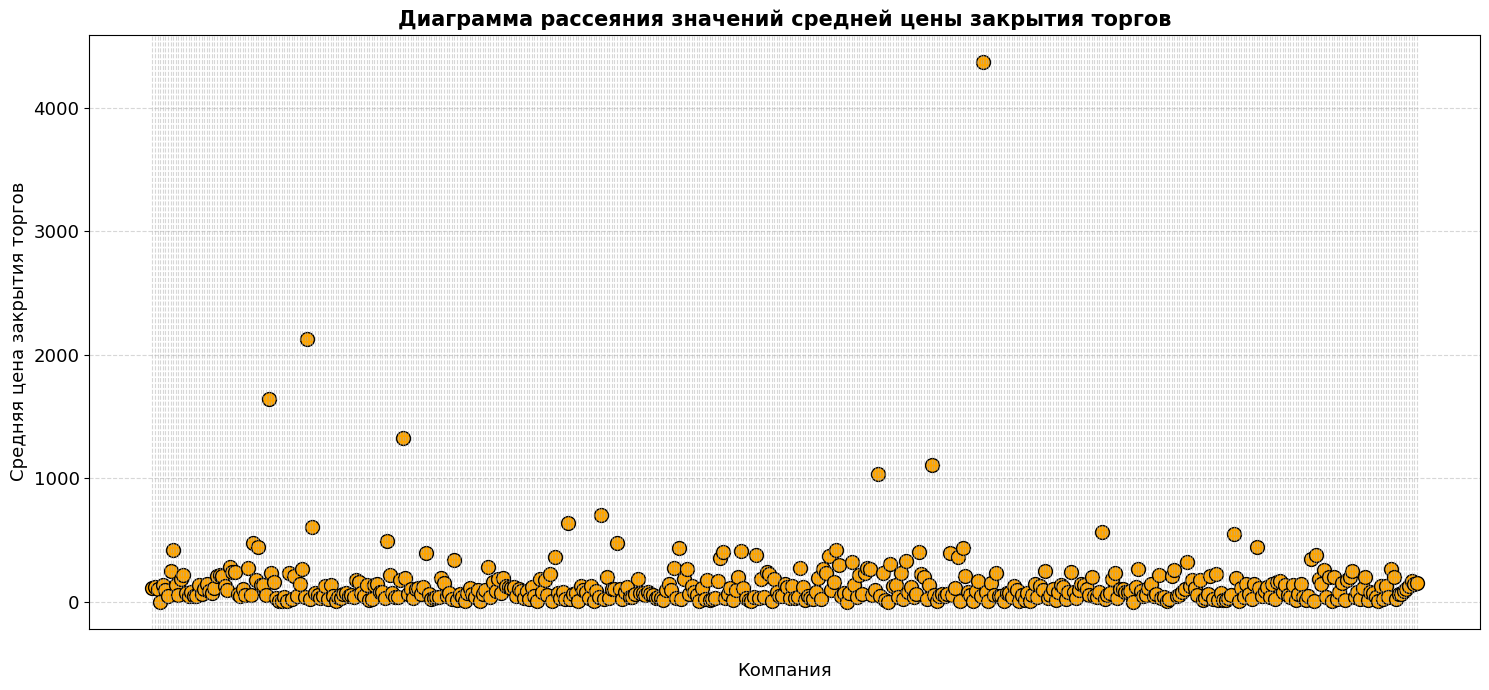

In [28]:
x = df_mean_close['Company']
y = df_mean_close['Mean_Close']

plt.figure(figsize=(15, 7))
plt.rc('xtick', color='white')
plt.tick_params(
    axis='both',
    which='major',
    labelsize=13
)

plt.scatter(
    x,
    y,
    color='orange',
    edgecolor='k',
    s=100
)

plt.xlabel("Компания", fontsize=13)
plt.ylabel("Средняя цена закрытия торгов", fontsize=13)
plt.title(
    "Диаграмма рассеяния значений средней цены закрытия торгов",
    fontsize=15,
    fontweight='bold'
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

В данных есть несколько значений, существенно отклоняющихся от среднего значения.

Ориентируясь по графику, выводим перечень компаний, по которым наблюдается существенное отклонение от среднего значения в большую сторону.

In [29]:
max_mean_close = df_mean_close.loc[
    df_mean_close['Mean_Close'] > 1000
]

display(max_mean_close)

,Company,Mean_Close
45,AZO,1645.242242
60,BKNG,2126.469873
97,CMG,1324.551017
281,MELI,1032.793749
302,MTD,1107.243361
322,NVR,4369.628335


Для дальнейшего исследования и использования данных для разработки моделей прогнозирования необходимо преобразование столбца «Date». Выделяем в отдельные столбцы год, месяц, день с помощью атрибутов dt.year, dt.month, dt.day. 

In [30]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day

display(data)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company,Year,Month,Day
0,2018-11-29,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL,2018,11,29
1,2018-11-29,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT,2018,11,29
2,2018-11-29,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL,2018,11,29
3,2018-11-29,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN,2018,11,29
4,2018-11-29,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA,2018,11,29
...,...,...,...,...,...,...,...,...,...,...,...,...
602957,2023-11-29,26.360001,26.397499,26.120001,26.150000,1729147,0.00,0.0,PPL,2023,11,29
602958,2023-11-29,27.680000,28.535000,27.680000,28.350000,1940066,0.00,0.0,FITB,2023,11,29
602959,2023-11-29,75.940002,76.555000,75.257500,75.610001,298699,0.00,0.0,IFF,2023,11,29
602960,2023-11-29,45.230000,45.259998,44.040001,44.209999,2217579,0.00,0.0,CCJ,2023,11,29


Визуализируем динамику изменения цены закрытия торгов за весь период наблюдения по выбранной компании, а также одновременно по трем компаниям для сравнительного анализа. Поскольку компаний достаточно много, смотреть на графике динамику одновременно по всем компаниям не совсем информативно, поэтому можно посмотреть динамику по одной или трем выбранным компаниям. Информацию с кратким буквенным обозначением компании необходимо ввести в поле для ввода данных Input. Оценив динамику изменения цены закрытия торгов, можно сделать предположение о том, является ли временной ряд стационарным или нет.

Введите название компании:  PPL


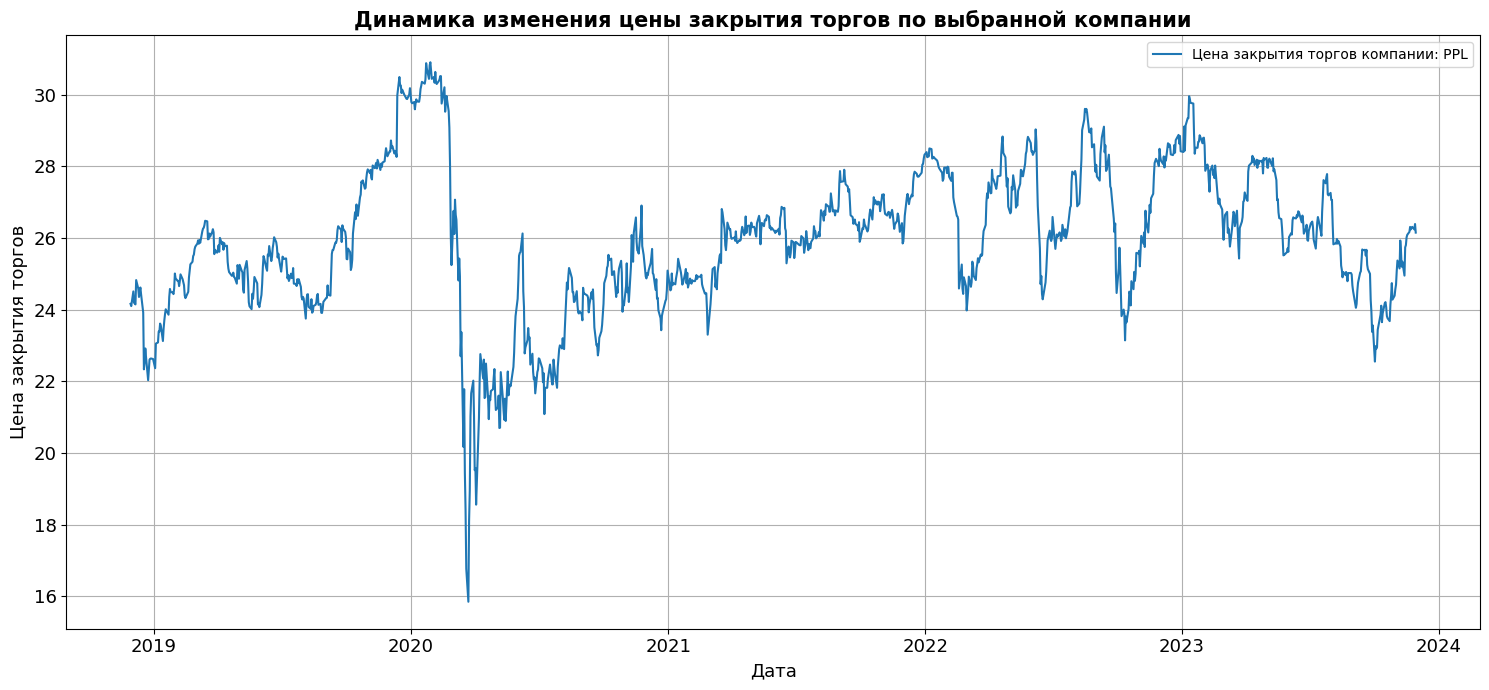

In [31]:
company = input(
    "Введите название компании: "
)

plt.figure(figsize=(15, 7))
plt.rc('xtick', color='black')
plt.tick_params(
    axis='both',
    which='major',
    labelsize=13
)

sns.lineplot(
    x='Date',
    y='Close',
    data=data[data['Company'] == company],
    label=f'Цена закрытия торгов компании: {company}'
)

plt.xlabel("Дата", fontsize=13)
plt.ylabel("Цена закрытия торгов", fontsize=13)
plt.title(
    "Динамика изменения цены закрытия торгов по выбранной компании",
    fontsize=15,
    fontweight='bold'
)

plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

Введите название компании:  PPL
Введите название компании:  AAPL
Введите название компании:  LYV


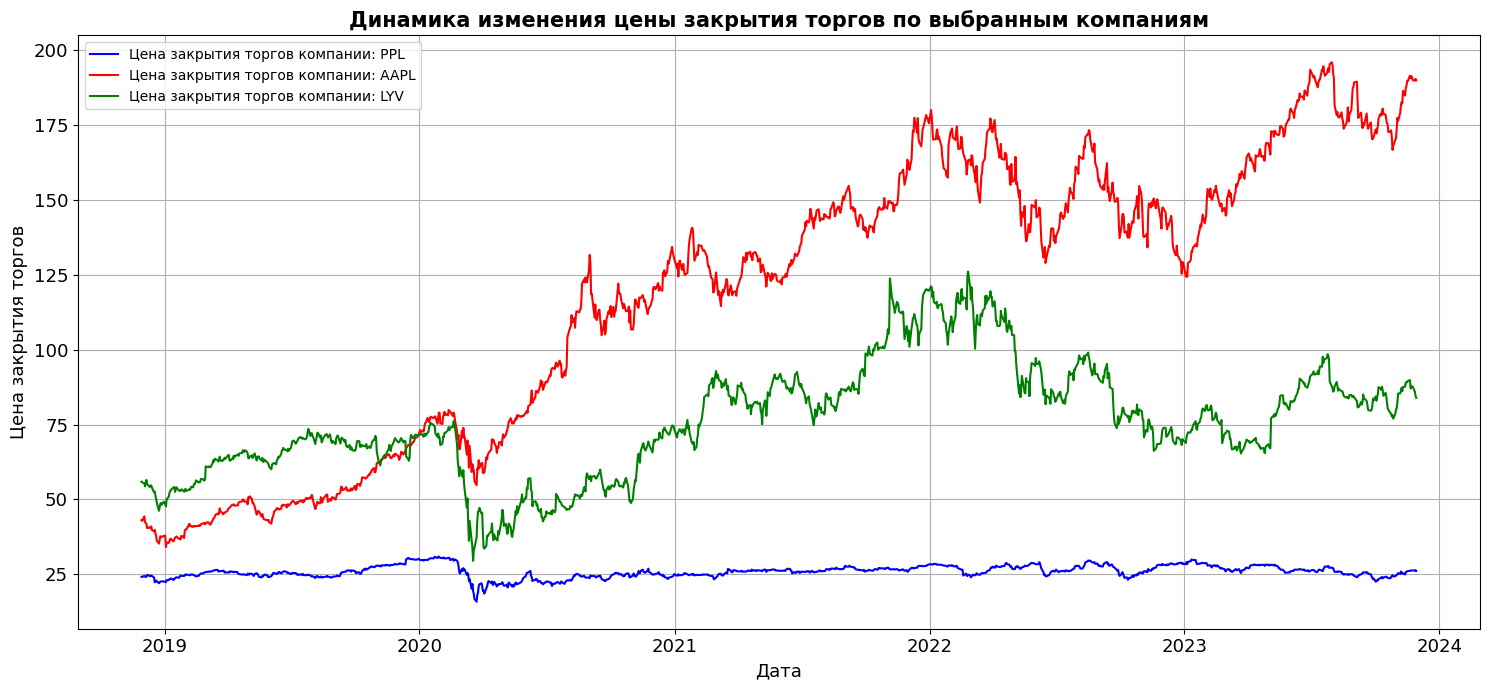

In [32]:
company_1 = input(
    "Введите название компании: "
)
company_2 = input(
    "Введите название компании: "
)
company_3 = input(
    "Введите название компании: "
)

plt.figure(figsize=(15, 7))
plt.rc('xtick', color='black')
plt.tick_params(
    axis='both',
    which='major',
    labelsize=13
)

sns.lineplot(
    x='Date',
    y='Close',
    data=data[data['Company'] == company_1],
    label=f'Цена закрытия торгов компании: {company_1}',
    color="b"
)

sns.lineplot(
    x='Date',
    y='Close',
    data=data[data['Company'] == company_2],
    label=f'Цена закрытия торгов компании: {company_2}',
    color="r"
)

sns.lineplot(
    x='Date',
    y='Close',
    data=data[data['Company'] == company_3],
    label=f'Цена закрытия торгов компании: {company_3}',
    color="g"
)

plt.xlabel("Дата", fontsize=13)
plt.ylabel("Цена закрытия торгов", fontsize=13)
plt.title(
    "Динамика изменения цены закрытия торгов по выбранным компаниям",
    fontsize=15,
    fontweight='bold'
)

plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

Выше представленный код можно оптимизировать, применив циклы.

Введите название компании 1:  PPL
Введите название компании 2:  AAPL
Введите название компании 3:  LYV


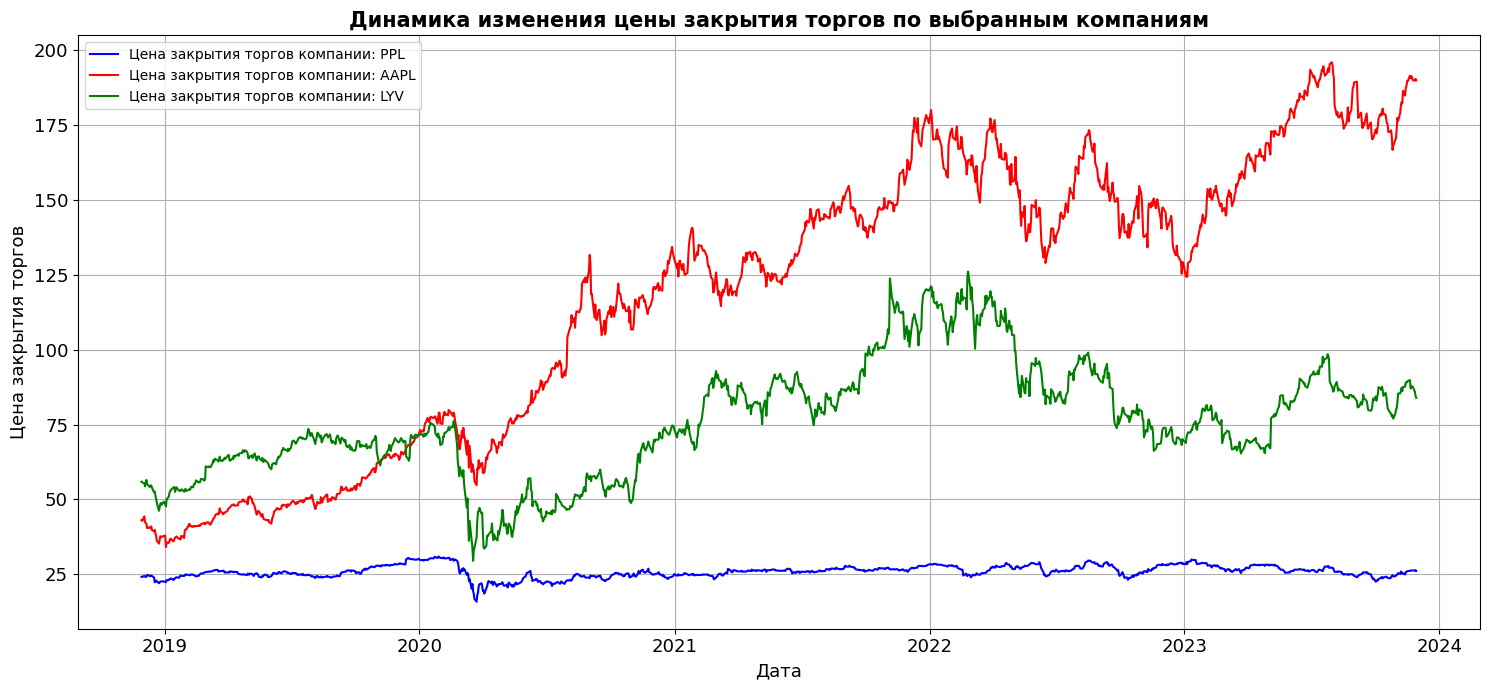

In [33]:
companies = []
for i in range(1, 4):
    company_name = input(f"Введите название компании {i}: ")
    companies.append(company_name)

plt.figure(figsize=(15, 7))
plt.rc('xtick', color='black')
plt.tick_params(
    axis='both',
    which='major',
    labelsize=13
)

colors = ["b", "r", "g"]

for company, color in zip(companies, colors):
    sns.lineplot(
        x='Date',
        y='Close',
        data=data[data['Company'] == company],
        label=f'Цена закрытия торгов компании: {company}',
        color=color
    )

plt.xlabel("Дата", fontsize=13)
plt.ylabel("Цена закрытия торгов", fontsize=13)
plt.title(
    "Динамика изменения цены закрытия торгов по выбранным компаниям",
    fontsize=15,
    fontweight='bold'
)

plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

Удаляем ранее преобразованный столбец «Date» функцией drop().

In [34]:
data_new = data.drop(['Date'], axis=1)

display(data_new)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company,Year,Month,Day
0,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL,2018,11,29
1,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT,2018,11,29
2,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL,2018,11,29
3,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN,2018,11,29
4,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA,2018,11,29
...,...,...,...,...,...,...,...,...,...,...,...
602957,26.360001,26.397499,26.120001,26.150000,1729147,0.00,0.0,PPL,2023,11,29
602958,27.680000,28.535000,27.680000,28.350000,1940066,0.00,0.0,FITB,2023,11,29
602959,75.940002,76.555000,75.257500,75.610001,298699,0.00,0.0,IFF,2023,11,29
602960,45.230000,45.259998,44.040001,44.209999,2217579,0.00,0.0,CCJ,2023,11,29


Выводим среднюю по годам цену закрытия торгов по компаниям. Находим среднее значение столбца «Close» для каждой комбинации значений столбцов «Company» и «Year»: groupby(['Company', 'Year'])['Close'].mean(). Затем полученные результаты преобразуем в DataFrame и выводим график с динамикой изменения средней по годам цены закрытия торгов за весь период наблюдений по всем компаниям для визуализации разброса динамики средней цены закрытия торгов. Добавляем на график метки с названиями компаний.

In [35]:
year_close = data_new.groupby(['Company', 'Year'])['Close'].mean()

print(
    "Средняя по годам цена закрытия торгов по компаниям:\n",
    year_close
)

Средняя по годам цена закрытия торгов по компаниям:
 Company  Year
A        2018     66.438090
         2019     72.929442
         2020     90.516794
         2021    142.471051
         2022    131.681523
                    ...    
ZTS      2019    107.136584
         2020    141.352767
         2021    185.217927
         2022    169.156711
         2023    171.615852
Name: Close, Length: 2874, dtype: float64


In [36]:
df_year_close = pd.DataFrame(year_close)
print(df_year_close)

                   Close
Company Year            
A       2018   66.438090
        2019   72.929442
        2020   90.516794
        2021  142.471051
        2022  131.681523
...                  ...
ZTS     2019  107.136584
        2020  141.352767
        2021  185.217927
        2022  169.156711
        2023  171.615852

[2874 rows x 1 columns]


In [37]:
df_year_close = df_year_close.reset_index()
display(df_year_close)

,Company,Year,Close
0,A,2018,66.438090
1,A,2019,72.929442
2,A,2020,90.516794
3,A,2021,142.471051
4,A,2022,131.681523
...,...,...,...
2869,ZTS,2019,107.136584
2870,ZTS,2020,141.352767
2871,ZTS,2021,185.217927
2872,ZTS,2022,169.156711


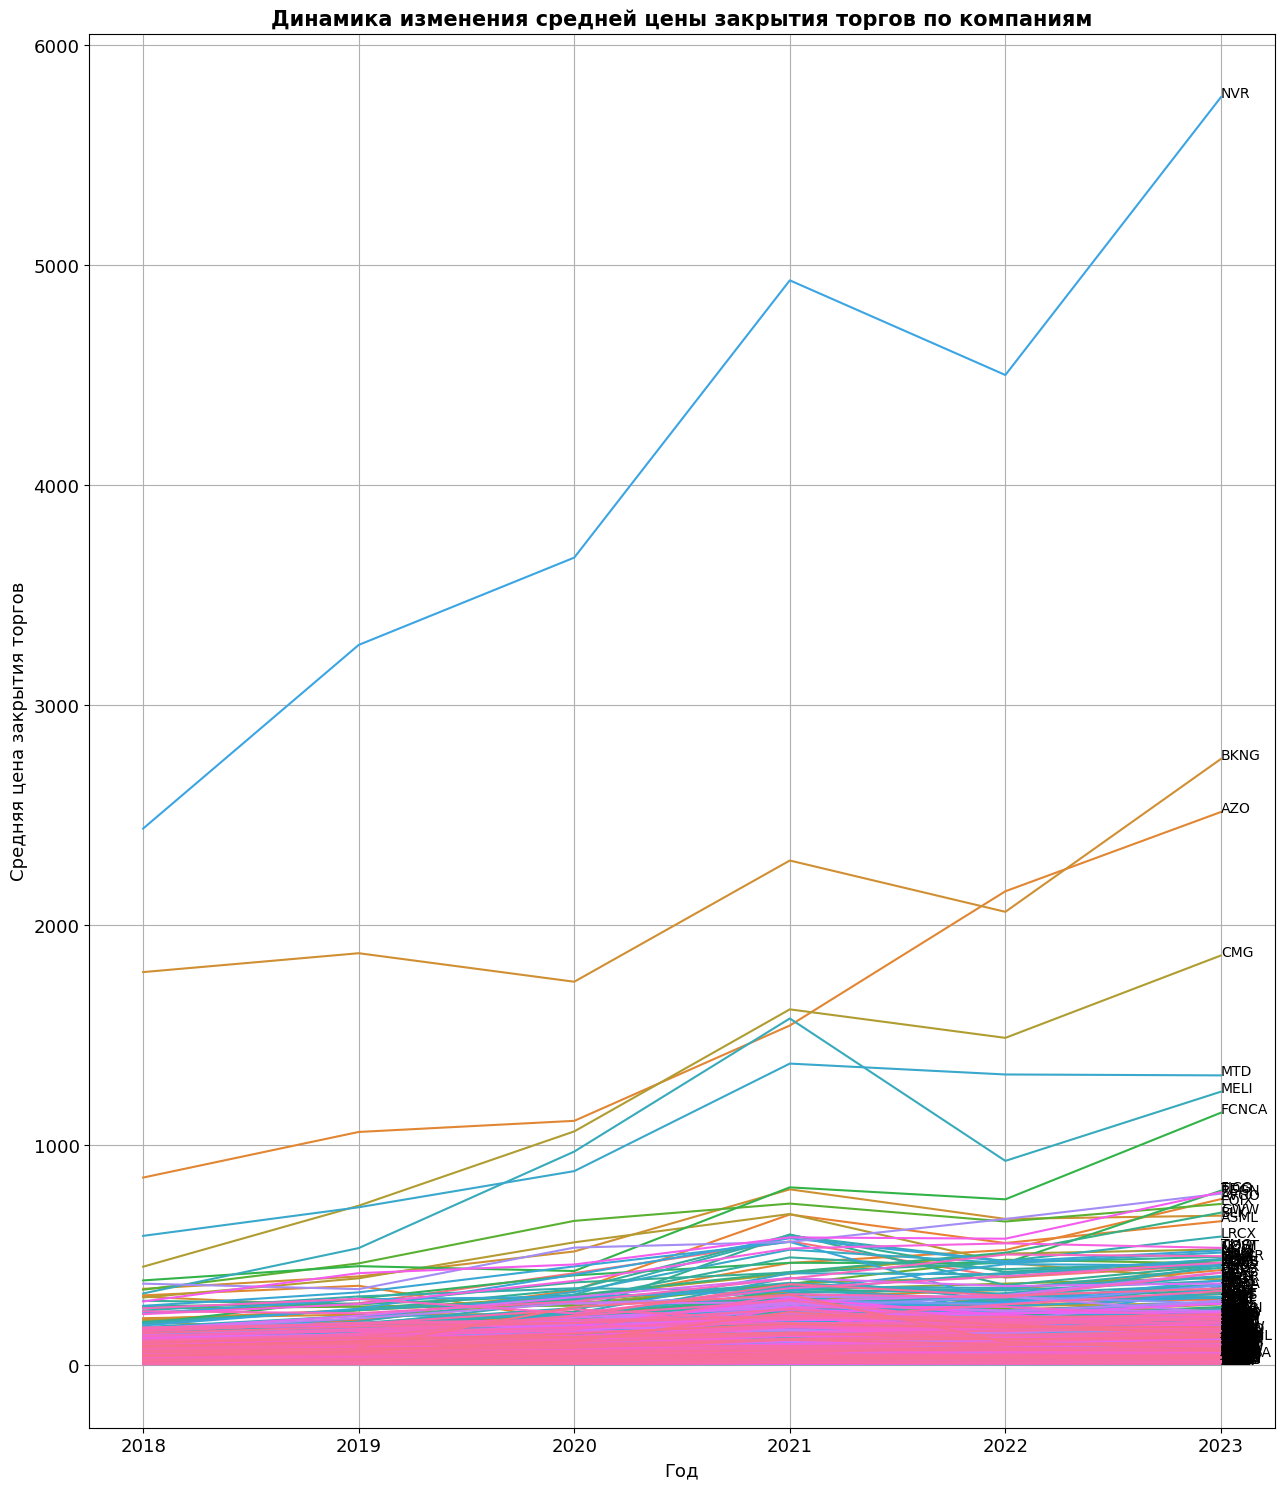

In [38]:
plt.figure(figsize=(13, 15))
plt.rc('xtick', color='black')
plt.tick_params(
    axis='both',
    which='major',
    labelsize=13
)

ax = sns.lineplot(
    data=df_year_close,
    x='Year',
    y='Close',
    hue='Company',
    legend=None
)

for company in df_year_close['Company'].unique():
    company_data = df_year_close[df_year_close['Company'] == company]

    last_year = company_data['Year'].max()
    last_close = company_data[
        company_data['Year'] == last_year
        ]['Close'].values[0]

    ax.annotate(company, (last_year, last_close))

plt.xlabel("Год", fontsize=13)
plt.ylabel("Средняя цена закрытия торгов", fontsize=13)
plt.title(
    "Динамика изменения средней цены закрытия торгов по компаниям",
    fontsize=15,
    fontweight='bold'
)

plt.grid(True)
plt.tight_layout()
plt.show()

Столбец «Company» имеет тип данных object. Для дальнейшего исследования данных и использования данных для разработки моделей прогнозирования необходимо преобразование столбца «Company». Данные не имеют естественного порядка, но содержат большое количество уникальных значений, поэтому для преобразования категориальной переменной в данном случае используем метод Target Encoding. Target Encoding в отличие от One Hot Encoding не создает множество новых столбцов, что позволяет экономить время обучения модели.

In [39]:
encoder = ce.TargetEncoder(cols=['Company'])

data_result_1 = encoder.fit_transform(
    data_new,
    data_new['Company']
)

display(data_result_1)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company,Year,Month,Day
0,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,1.0,2018,11,29
1,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,298.0,2018,11,29
2,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,199.0,2018,11,29
3,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,28.0,2018,11,29
4,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,320.0,2018,11,29
...,...,...,...,...,...,...,...,...,...,...,...
602957,26.360001,26.397499,26.120001,26.150000,1729147,0.00,0.0,354.0,2023,11,29
602958,27.680000,28.535000,27.680000,28.350000,1940066,0.00,0.0,182.0,2023,11,29
602959,75.940002,76.555000,75.257500,75.610001,298699,0.00,0.0,229.0,2023,11,29
602960,45.230000,45.259998,44.040001,44.209999,2217579,0.00,0.0,84.0,2023,11,29


In [40]:
data_result_1.dtypes

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
Company         float64
Year              int32
Month             int32
Day               int32
dtype: object

Создаем матрицу корреляции и визуализируем результат в виде тепловой карты. Добавляем числовые значения с двумя знаками после запятой в каждую ячейку тепловой карты. По результатам видно, что максимальная корреляция присутствует между ценой открытия торгов, ценой закрытия торгов, а также колебаниями в течение дня.

In [41]:
numeric_data = data_result_1.select_dtypes(
    include=[
        'float64',
        'int64',
        'int32']
)

correlation_matrix = numeric_data.corr()

display(correlation_matrix)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company,Year,Month,Day
Open,1.000000,0.999910,0.999898,0.999807,-0.096096,0.009417,-0.001256,-0.037197,0.087829,0.012013,-0.000206
High,0.999910,1.000000,0.999868,0.999907,-0.095561,0.009310,-0.001234,-0.037034,0.087802,0.011525,-0.000345
Low,0.999898,0.999868,1.000000,0.999911,-0.096634,0.009484,-0.001278,-0.037356,0.087945,0.012402,-0.000014
Close,0.999807,0.999907,0.999911,1.000000,-0.096093,0.009396,-0.001259,-0.037204,0.087868,0.011861,-0.000219
Volume,-0.096096,-0.095561,-0.096634,-0.096093,1.000000,-0.008840,0.016015,-0.021194,-0.002585,-0.027505,-0.000635
Dividends,0.009417,0.009310,0.009484,0.009396,-0.008840,1.000000,0.001282,-0.001697,0.005146,0.005507,0.001983
Stock Splits,-0.001256,-0.001234,-0.001278,-0.001259,0.016015,0.001282,1.000000,-0.001350,0.001198,0.000255,0.000166
Company,-0.037197,-0.037034,-0.037356,-0.037204,-0.021194,-0.001697,-0.001350,1.000000,-0.003952,-0.000198,-0.000059
Year,0.087829,0.087802,0.087945,0.087868,-0.002585,0.005146,0.001198,-0.003952,1.000000,-0.092116,-0.006801
Month,0.012013,0.011525,0.012402,0.011861,-0.027505,0.005507,0.000255,-0.000198,-0.092116,1.000000,0.003762


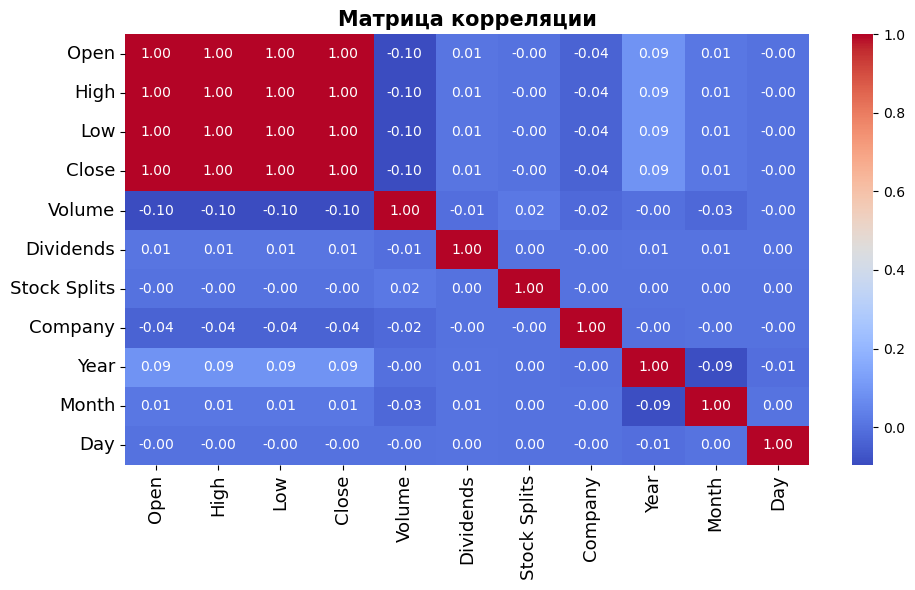

In [42]:
plt.figure(figsize=(10, 6))
plt.rc('xtick', color='black')
plt.tick_params(
    axis='both',
    which='major',
    labelsize=13
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    "Матрица корреляции",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

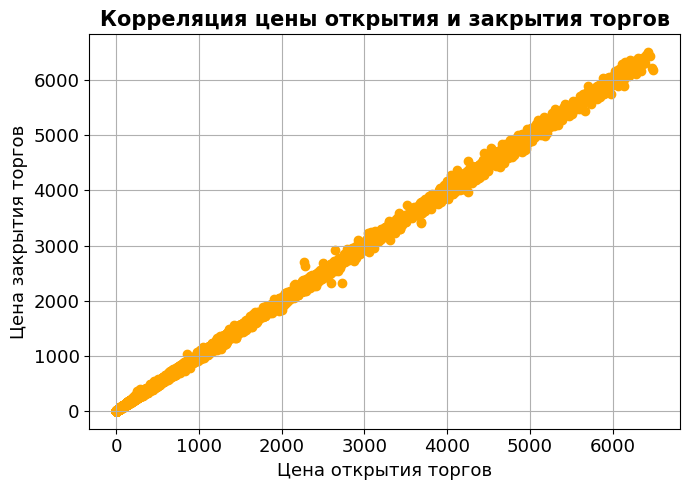

In [43]:
x = data['Open']
y = data['Close']

plt.figure(figsize=(7, 5))
plt.rc('xtick', color='black')
plt.tick_params(
    axis='both',
    which='major',
    labelsize=13
)

plt.scatter(x, y, color='orange')
plt.xlabel("Цена открытия торгов", fontsize=13)
plt.ylabel("Цена закрытия торгов", fontsize=13)
plt.title(
    "Корреляция цены открытия и закрытия торгов",
    fontsize=15,
    fontweight='bold'
)

plt.grid(True)
plt.tight_layout()
plt.show()

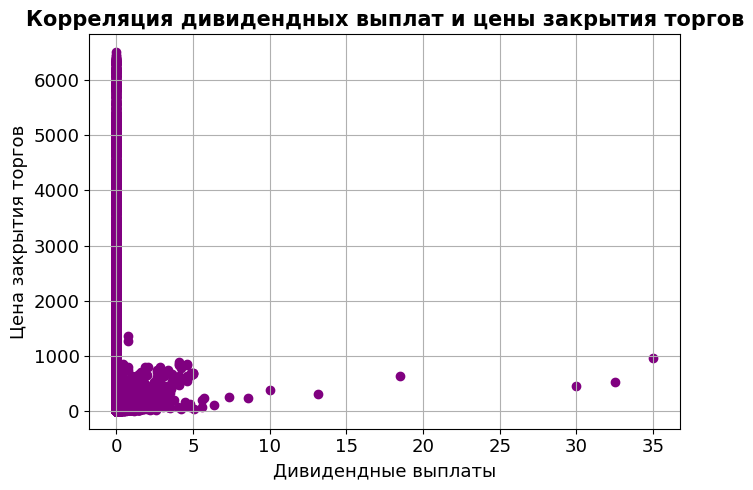

In [44]:
x = data['Dividends']
y = data['Close']

plt.figure(figsize=(7, 5))
plt.rc('xtick', color='black')
plt.tick_params(
    axis='both',
    which='major',
    labelsize=13
)

plt.scatter(x, y, color='purple')
plt.xlabel("Дивидендные выплаты", fontsize=13)
plt.ylabel("Цена закрытия торгов", fontsize=13)
plt.title(
    "Корреляция дивидендных выплат и цены закрытия торгов",
    fontsize=15,
    fontweight='bold'
)

plt.grid(True)
plt.tight_layout()
plt.show()

В процессе исследовательского анализа данных удалось изучить состав и структуру набора данных. Выявлены компании, по которым данные собраны не по всем датам, недостающие значения заменены на медиану для более точного анализа и визуализации данных. Выявлены компании с наиболее высокой средней ценой закрытия торгов. Благодаря визуализации динамики изменения цены закрытия торгов можно сделать предположение о том, является ли временной ряд стационарным или нет. Данная информация может быть полезна в разработке системы управления рисками и в создании индивидуальных инвестиционных стратегий. Сформирована матрица корреляции, позволяющая выявить наиболее важные признаки, что в дальнейшем будет использовано в процессе разработки моделей прогнозирования. Возможно предположение, что в наборе данных присутствуют избыточные признаки, которые могут ухудшать качество и увеличивать время обучения модели. Данная гипотеза будет проверена далее в процессе разработки моделей. Для дальнейшего использования данных с целью разработки моделей прогнозирования преобразованы нечисловые столбцы с датой и кратким буквенным обозначением компании.

<span style="color: orange;">**2. Разработка статистической модели ARIMA для анализа и прогнозирования временных рядов.**</span>

Модель ARIMA – статистическая модель для анализа и прогнозирования временных рядов. Она объединяет три основных компонента: авторегрессия, интегрирование, скользящее среднее. Авторегрессия использует прошлые значения временного ряда для предсказания будущих. Интегрирование делает временной ряд стационарным путем взятия разностей. Скользящее среднее учитывает прошлые ошибки прогноза. Компоненты модели: порядок авторегрессии (p) – количество предыдущих значений, используемых для прогнозирования; порядок интегрирования (d) – количество разностей, необходимых для достижения стационарности; порядок скользящего среднего (q) – количество прошлых ошибок, используемых в модели. 

ARIMA хорошо работает с временными рядами, но требует стационарности временного ряда. Стационарный временной ряд – это ряд, статистические свойства которого не меняются во времени, то есть среднее значение и дисперсия постоянны. Для проверки стационарности временного ряда проведем тест Дики-Фуллера.

In [45]:
def perform_adf_test(series):
    result = adfuller(series)
    return {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Value (1%)': result[4]['1%'],
        'Critical Value (5%)': result[4]['5%'],
        'Critical Value (10%)': result[4]['10%']
    }


adf_results = {}

for company in data_close.columns:
    try:
        prices = data_close[company]

        result = perform_adf_test(prices)

        adf_results[company] = result

        print(f"Результаты для {company}:")
        print(f"ADF Statistic: {result['ADF Statistic']}")
        print(f"p-value: {result['p-value']}")
        print(f"Критические значения:")
        print(f"  1%: {result['Critical Value (1%)']}")
        print(f"  5%: {result['Critical Value (5%)']}")
        print(f"  10%: {result['Critical Value (10%)']}")
        print("-" * 40)

    except Exception as e:
        print(f"Ошибка при обработке {company}: {str(e)}")


df_adf_result = pd.DataFrame(adf_results).T

Результаты для A:
ADF Statistic: -1.5301005427431957
p-value: 0.5185719832515249
Критические значения:
  1%: -3.4355880246374304
  5%: -2.8638531175675896
  10%: -2.568001531098063
----------------------------------------
Результаты для AAPL:
ADF Statistic: -0.9835736053356359
p-value: 0.759208205604656
Критические значения:
  1%: -3.4355629707955395
  5%: -2.863842063387667
  10%: -2.567995644141416
----------------------------------------
Результаты для ABBV:
ADF Statistic: -0.923762303375191
p-value: 0.7800464721280467
Критические значения:
  1%: -3.4356048614183443
  5%: -2.8638605461891617
  10%: -2.5680054872544145
----------------------------------------
Результаты для ABEV:
ADF Statistic: -2.1319383010431414
p-value: 0.23186744328768422
Критические значения:
  1%: -3.435571295403709
  5%: -2.863845736356174
  10%: -2.567997600196822
----------------------------------------
Результаты для ABNB:
ADF Statistic: -2.4717312564646683
p-value: 0.12250477716904523
Критические значения:

Результаты теста Дики-Фуллера представлены в таблице.

In [46]:
display(df_adf_result)

,ADF Statistic,p-value,Critical Value (1%),Critical Value (5%),Critical Value (10%)
A,-1.530101,0.518572,-3.435588,-2.863853,-2.568002
AAPL,-0.983574,0.759208,-3.435563,-2.863842,-2.567996
ABBV,-0.923762,0.780046,-3.435605,-2.863861,-2.568005
ABEV,-2.131938,0.231867,-3.435571,-2.863846,-2.567998
ABNB,-2.471731,0.122505,-3.435613,-2.863864,-2.568007
...,...,...,...,...,...
YUM,-1.694259,0.434073,-3.435563,-2.863842,-2.567996
ZBH,-2.973498,0.037445,-3.435592,-2.863855,-2.568003
ZM,-1.480750,0.543011,-3.435652,-2.863881,-2.568016
ZS,-1.583503,0.491875,-3.435605,-2.863861,-2.568005


Временной ряд можно считать стационарным, если ADF Statistic (статистика Дики-Фуллера) < критического значения и p-value (уровень значимости) < 0.05.

In [47]:
stationary = df_adf_result[
    (df_adf_result['ADF Statistic'] < df_adf_result['Critical Value (10%)']) &
    (df_adf_result['p-value'] < 0.05)
]
display(stationary)

,ADF Statistic,p-value,Critical Value (1%),Critical Value (5%),Critical Value (10%)
AEP,-2.869192,4.904963e-02,-3.435618,-2.863866,-2.568008
ARM,-14.629387,3.773319e-27,-3.435660,-2.863885,-2.568019
BDX,-3.818669,2.721976e-03,-3.435605,-2.863861,-2.568005
BIIB,-3.090076,2.729637e-02,-3.435588,-2.863853,-2.568002
ETR,-3.343287,1.305099e-02,-3.435639,-2.863876,-2.568013
FTV,-2.879900,4.773579e-02,-3.435605,-2.863861,-2.568005
GEHC,-3.721085,3.826166e-03,-3.435660,-2.863885,-2.568019
GFS,-6.352162,2.594891e-08,-3.435639,-2.863876,-2.568013
HLN,-2.985156,3.630412e-02,-3.435652,-2.863881,-2.568016
KMB,-3.519781,7.493376e-03,-3.435601,-2.863859,-2.568004


Подбираем оптимальные компоненты модели, создаем модель на основе лучших найденных значений, выводим визуализацию и метрики оценки качества модели.

In [72]:
import itertools
import warnings
warnings.filterwarnings("ignore")

company = input("Введите название компании: ")

series = data_close[company]

train_size = int(len(series) * 0.8)
train_close, test_close = series[:train_size], series[train_size:]

p_values = range(0, 3)
d_values = range(0, 3)
q_values = range(0, 3)

param_grid = list(itertools.product(
    p_values,
    d_values,
    q_values
)
                 )


def evaluate_arima_model(X, arima_order):
    try:
        model = ARIMA(X, order=arima_order)
        model_fit = model.fit()

        predictions = model_fit.forecast(
            steps=len(test_close)
        )

        error = mean_squared_error(
            test_close,
            predictions
        )
        return error
    except Exception:
        return None


results = {}

for param in param_grid:
    try:
        error = evaluate_arima_model(
            train_close,
            param
        )
        if error is not None:
            results[param] = error
    except Exception:
        continue

if results:
    best_params = min(results, key=results.get)
    print(f'\nЛучшие компоненты: ARIMA{best_params}')
else:
    print("Не удалось найти подходящие параметры модели")

Введите название компании:  LI



Лучшие компоненты: ARIMA(1, 0, 2)


In [73]:
train_close, test_close = train_test_split(
    data_close,
    test_size=0.3,
    shuffle=False
)

In [74]:
p, d, q = 1, 0, 2
arima = sm.tsa.ARIMA(train_close[company], order=(p, d, q))
model_arima = arima.fit()

In [75]:
display(model_arima)

In [76]:
forecast = model_arima.forecast(
    steps=test_close.shape[0]
)

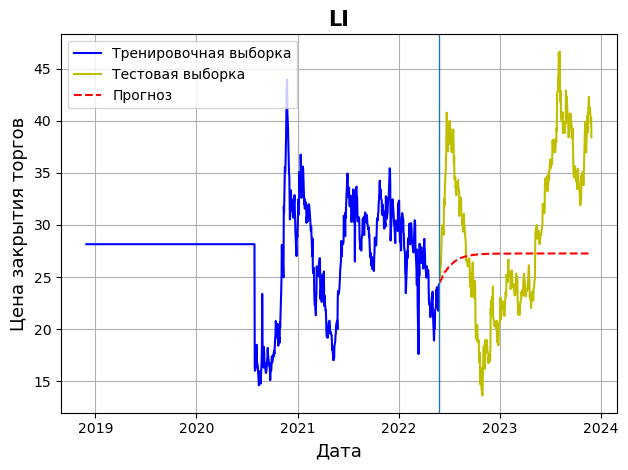

In [77]:
plt.rc('xtick', color='black')

plt.plot(
    pd.to_datetime(train_close.index).values.reshape(-1, 1),
    train_close[company].values.reshape(-1, 1),
    color='b',
    label='Тренировочная выборка'
)

plt.plot(
    pd.to_datetime(test_close.index).values.reshape(-1, 1),
    test_close[company].values.reshape(-1, 1),
    color='y',
    label='Тестовая выборка'
)

plt.plot(
    pd.to_datetime(test_close.index).values.reshape(-1, 1),
    forecast.values.reshape(-1, 1),
    color='r',
    linestyle='--',
    label='Прогноз'
)

plt.axvline(train_close.index[-1], linewidth=1)
plt.xlabel('Дата', fontsize=13)
plt.ylabel('Цена закрытия торгов', fontsize=13)
plt.title(
    company,
    fontsize=15,
    fontweight='bold'
)

plt.legend(loc='best')
plt.grid()
plt.tight_layout()
plt.show()

In [78]:
MSE_ARIMA = mean_squared_error(test_close[company], forecast)
r2_score_ARIMA = r2_score(test_close[company], forecast)

print(f"Test MSE: {MSE_ARIMA:.6f}")
print(f"Test r2-score: {r2_score_ARIMA:.6f}")

Test MSE: 66.115330
Test r2-score: -0.120482


Построим гистограмму распределения остатков. Гистограмма распределения остатков должна быть близка к нормальному распределению.

<Figure size 700x500 with 0 Axes>

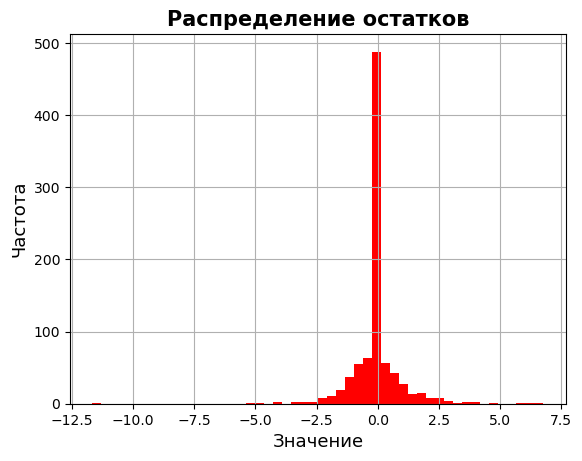

In [79]:
residuals = pd.DataFrame(model_arima.resid)

plt.figure(figsize=(7, 5))
plt.rc('xtick', color='black')
residuals.hist(bins=50, color='red')

plt.xlabel("Значение", fontsize=13)
plt.ylabel("Частота", fontsize=13)
plt.title(
    "Распределение остатков",
    fontsize=15,
    fontweight='bold'
)

plt.show()

Модель ARIMA возможно применять для прогнозирования цен акций в качестве дополнительного полезного инструмента в арсенале трейдера и аналитика, однако, волатильность цен может оказать негативное влияние на качество модели, важным требованием является стационарность временного ряда, а также в зависимости от особенностей временного ряда модель требует детальной настройки.